In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [3]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")
performance = pd.read_csv("../data/processed/clean_performance.csv")
benchmark = pd.read_csv("../data/processed/clean_benchmark.csv")

In [4]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [5]:
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [6]:
benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [7]:
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [9]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


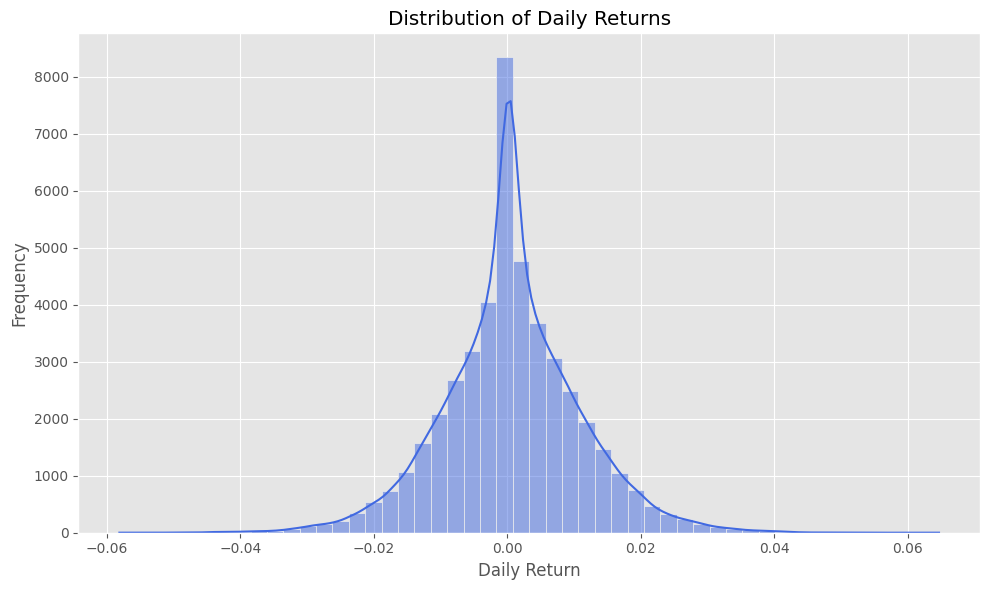

In [10]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../reports/daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [11]:
years = [1, 3, 5]

cagr_results = []

for fund in nav["amfi_code"].unique():

    df = nav[nav["amfi_code"] == fund].sort_values("date")

    for y in years:

        trading_days = y * 252

        if len(df) >= trading_days:

            start_nav = df.iloc[-trading_days]["nav"]
            end_nav = df.iloc[-1]["nav"]

            cagr = ((end_nav / start_nav) ** (1 / y) - 1) * 100

            cagr_results.append({
                "amfi_code": fund,
                "Years": y,
                "CAGR (%)": round(cagr, 2)
            })

In [12]:
cagr_df = pd.DataFrame(cagr_results)

cagr_df.head()

,amfi_code,Years,CAGR (%)
0,100016,1,-3.31
1,100016,3,-0.03
2,100025,1,2.50
3,100025,3,4.61
4,100033,1,47.73


In [13]:
cagr_df = cagr_df.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

cagr_df.head()

,amfi_code,Years,CAGR (%),scheme_name
0,100016,1,-3.31,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,3,-0.03,HDFC Top 100 Fund - Regular Plan - Growth
2,100025,1,2.50,HDFC Short Term Debt Fund - Regular - Growth
3,100025,3,4.61,HDFC Short Term Debt Fund - Regular - Growth
4,100033,1,47.73,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [14]:
cagr_table = cagr_df.pivot_table(
    index="scheme_name",
    columns="Years",
    values="CAGR (%)"
)

cagr_table.head()

Years,1,3
scheme_name,,
ABSL Frontline Equity Fund - Regular - Growth,45.09,32.53
ABSL Liquid Fund - Regular - Growth,6.85,6.08
ABSL Small Cap Fund - Regular - Growth,-24.24,-2.70
Axis Bluechip Fund - Direct - Growth,19.79,20.58
Axis Bluechip Fund - Regular - Growth,3.40,0.56


In [15]:
cagr_table.to_csv(
    "../reports/cagr_comparison.csv"
)

print("CAGR table saved successfully.")

CAGR table saved successfully.


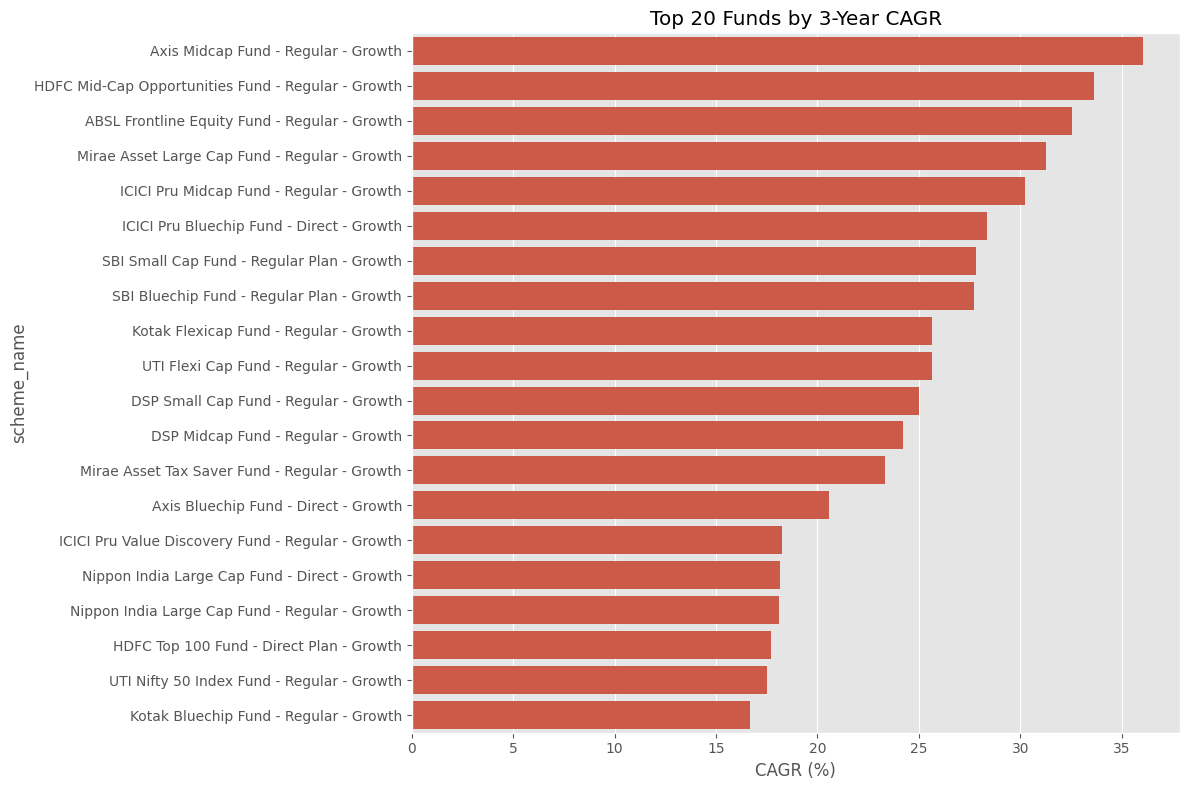

In [19]:
plt.figure(figsize=(12,8))

top20 = (
    cagr_df[cagr_df["Years"] == 3]
    .sort_values("CAGR (%)", ascending=False)
    .head(20)
)

sns.barplot(
    data=top20,
    x="CAGR (%)",
    y="scheme_name"
)

plt.title("Top 20 Funds by 3-Year CAGR")
plt.tight_layout()

plt.savefig(
    "../reports/cagr_top20.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [21]:
daily_returns = nav.copy()

daily_returns = daily_returns.sort_values(
    ["amfi_code", "date"]
)

daily_returns["daily_return"] = (
    daily_returns
    .groupby("amfi_code")["nav"]
    .pct_change()
)

daily_returns.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [22]:
daily_returns = daily_returns.dropna()

daily_returns.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [23]:
risk_free = 0.065

stats = (
    daily_returns
    .groupby("amfi_code")["daily_return"]
    .agg(["mean", "std"])
    .reset_index()
)

stats.head()

,amfi_code,mean,std
0,100016,0.000142,0.009164
1,100025,0.000170,0.002460
2,100033,0.001080,0.011929
3,101206,0.000852,0.009177
4,101207,0.000424,0.016251


In [24]:
import numpy as np

stats["Sharpe Ratio"] = (
    (
        stats["mean"] - risk_free / 252
    )
    /
    stats["std"]
) * np.sqrt(252)

stats.head()

,amfi_code,mean,std,Sharpe Ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [25]:
stats = stats.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

stats.head()

,amfi_code,mean,std,Sharpe Ratio,scheme_name
0,100016,0.000142,0.009164,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.000170,0.002460,-0.567095,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.000424,0.016251,0.162661,ABSL Small Cap Fund - Regular - Growth


In [26]:
stats.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

print("Sharpe Ratio CSV saved.")

Sharpe Ratio CSV saved.


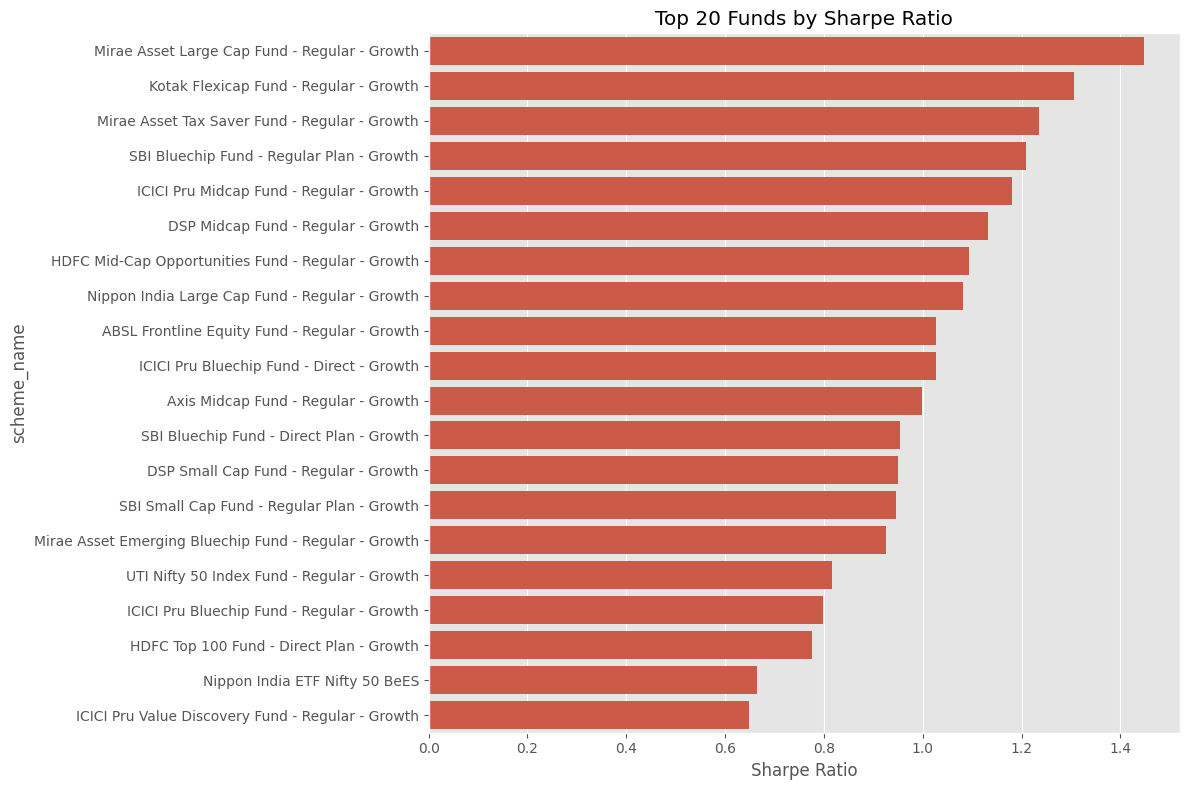

In [27]:
top20 = (
    stats
    .sort_values(
        "Sharpe Ratio",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20,
    x="Sharpe Ratio",
    y="scheme_name"
)

plt.title("Top 20 Funds by Sharpe Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/sharpe_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

plt.close()

In [28]:
downside = daily_returns.copy()

downside["downside_return"] = downside["daily_return"].where(
    downside["daily_return"] < 0
)

downside.head()

,amfi_code,date,nav,daily_return,downside_return
1,100016,2022-01-04,515.0971,-0.010306,-0.010306
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,-0.001210
5,100016,2022-01-10,510.7136,-0.008639,-0.008639


In [29]:
downside_std = (
    downside.groupby("amfi_code")["downside_return"]
    .std()
    .reset_index()
)

downside_std.head()

,amfi_code,downside_return
0,100016,0.005261
1,100025,0.001481
2,100033,0.007133
3,101206,0.005238
4,101207,0.009555


In [30]:
sortino = stats.merge(
    downside_std,
    on="amfi_code"
)

sortino.head()

,amfi_code,mean,std,Sharpe Ratio,scheme_name,downside_return
0,100016,0.000142,0.009164,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth,0.005261
1,100025,0.000170,0.002460,-0.567095,HDFC Short Term Debt Fund - Regular - Growth,0.001481
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.007133
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth,0.005238
4,101207,0.000424,0.016251,0.162661,ABSL Small Cap Fund - Regular - Growth,0.009555


In [31]:
sortino["Sortino Ratio"] = (
    (
        sortino["mean"] - (0.065 / 252)
    )
    /
    sortino["downside_return"]
) * np.sqrt(252)

sortino.head()

,amfi_code,mean,std,Sharpe Ratio,scheme_name,downside_return,Sortino Ratio
0,100016,0.000142,0.009164,-0.201517,HDFC Top 100 Fund - Regular Plan - Growth,0.005261,-0.351047
1,100025,0.000170,0.002460,-0.567095,HDFC Short Term Debt Fund - Regular - Growth,0.001481,-0.941821
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.007133,1.829134
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth,0.005238,1.799563
4,101207,0.000424,0.016251,0.162661,ABSL Small Cap Fund - Regular - Growth,0.009555,0.276644


In [32]:
sortino.to_csv(
    "../reports/sortino_ratio.csv",
    index=False
)

print("Sortino Ratio CSV saved.")

Sortino Ratio CSV saved.


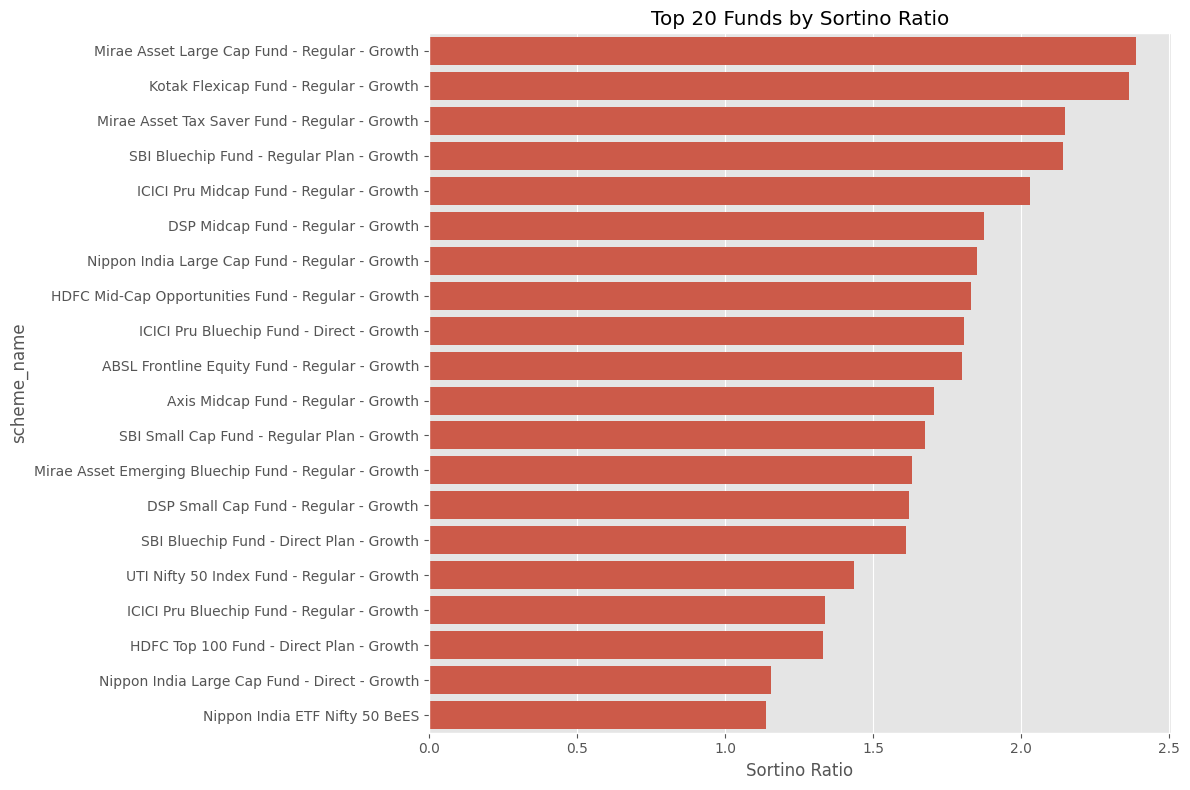

In [33]:
top20 = (
    sortino.sort_values(
        "Sortino Ratio",
        ascending=False
    )
    .head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20,
    x="Sortino Ratio",
    y="scheme_name"
)

plt.title("Top 20 Funds by Sortino Ratio")

plt.tight_layout()

plt.savefig(
    "../reports/sortino_ratio.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [34]:
from scipy.stats import linregress

In [35]:
benchmark = benchmark.sort_values("date")

benchmark["benchmark_return"] = (
    benchmark["close_value"].pct_change()
)

benchmark = benchmark.dropna()

benchmark.head()

,date,index_name,close_value,benchmark_return
5750,2022-01-03,CRISIL_LIQUID,2281.51,-0.869574
2300,2022-01-03,NIFTY_MIDCAP150,9721.79,3.261121
6900,2022-01-03,CRISIL_GILT,1451.06,-0.850741
1150,2022-01-03,NIFTY100,17778.24,11.251899
4600,2022-01-03,NIFTY500,14837.07,-0.165437


In [36]:
benchmark["index_name"].unique()

array(['CRISIL_LIQUID', 'NIFTY_MIDCAP150', 'CRISIL_GILT', 'NIFTY100',
       'NIFTY500', 'BSE_SMALLCAP', 'NIFTY50'], dtype=object)

In [38]:
benchmark100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

benchmark100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,11.251899
1151,2022-01-04,NIFTY100,17537.52,11.067710
1152,2022-01-05,NIFTY100,17607.73,0.176946
1153,2022-01-06,NIFTY100,17556.05,0.793714
1154,2022-01-07,NIFTY100,17664.02,-0.328795


In [39]:
merged = daily_returns.merge(
    benchmark100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,daily_return,benchmark_return
0,100016,2022-01-04,515.0971,-0.010306,11.067710
1,100016,2022-01-05,521.7239,0.012865,0.176946
2,100016,2022-01-06,515.7880,-0.011377,0.793714
3,100016,2022-01-07,515.1639,-0.001210,-0.328795
4,100016,2022-01-10,510.7136,-0.008639,-0.338402


In [40]:
print(merged.shape)

(45960, 5)


In [41]:
results = []

for fund in merged["amfi_code"].unique():

    temp = merged[merged["amfi_code"] == fund]

    slope, intercept, r_value, p_value, std_err = linregress(
        temp["benchmark_return"],
        temp["daily_return"]
    )

    results.append({
        "amfi_code": fund,
        "Alpha": intercept * 252,
        "Beta": slope
    })

In [42]:
alpha_beta = pd.DataFrame(results)

alpha_beta.head()

,amfi_code,Alpha,Beta
0,100016,0.023701,0.000020
1,100025,0.049041,-0.000010
2,100033,0.330252,-0.000098
3,101206,0.181075,0.000057
4,101207,0.058903,0.000081


In [43]:
alpha_beta = alpha_beta.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta.head()

,amfi_code,Alpha,Beta,scheme_name
0,100016,0.023701,0.000020,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.049041,-0.000010,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.330252,-0.000098,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.181075,0.000057,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.058903,0.000081,ABSL Small Cap Fund - Regular - Growth


In [44]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("Alpha Beta CSV Saved Successfully!")

Alpha Beta CSV Saved Successfully!


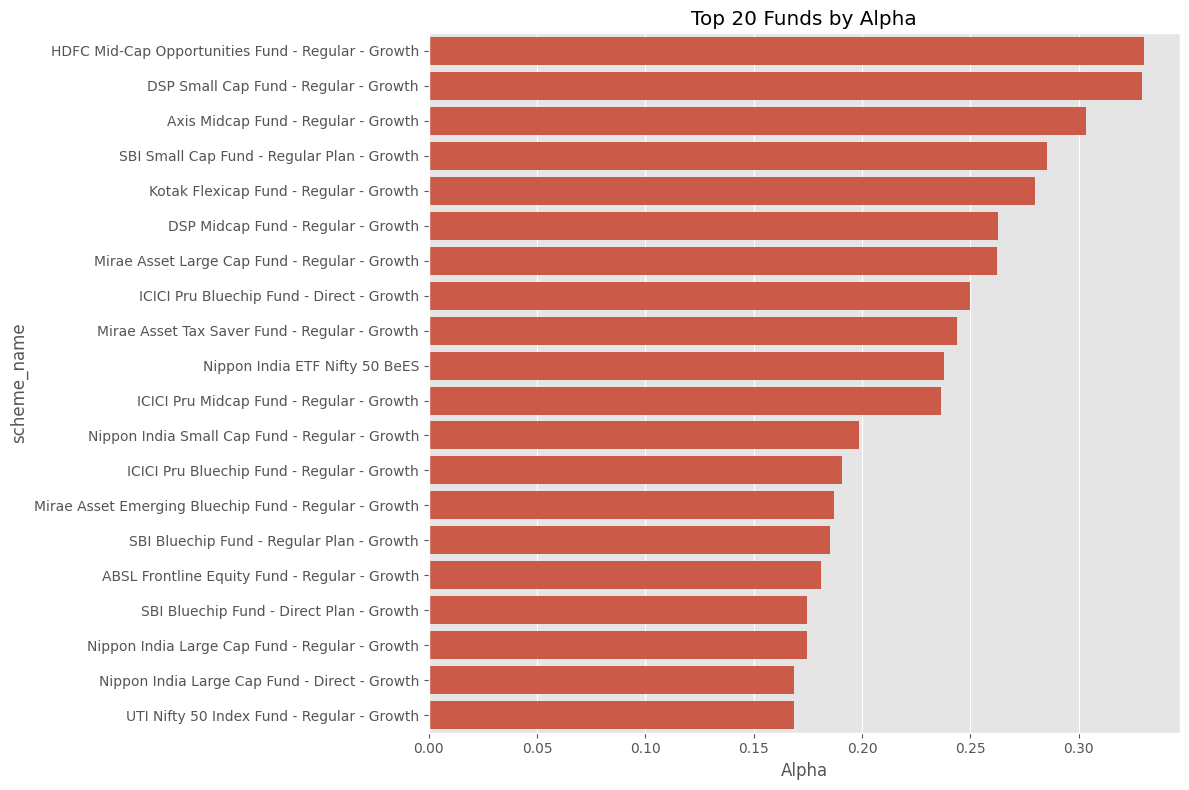

In [45]:
top20_alpha = (
    alpha_beta
    .sort_values("Alpha", ascending=False)
    .head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20_alpha,
    x="Alpha",
    y="scheme_name"
)

plt.title("Top 20 Funds by Alpha")

plt.tight_layout()

plt.savefig(
    "../reports/alpha_top20.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

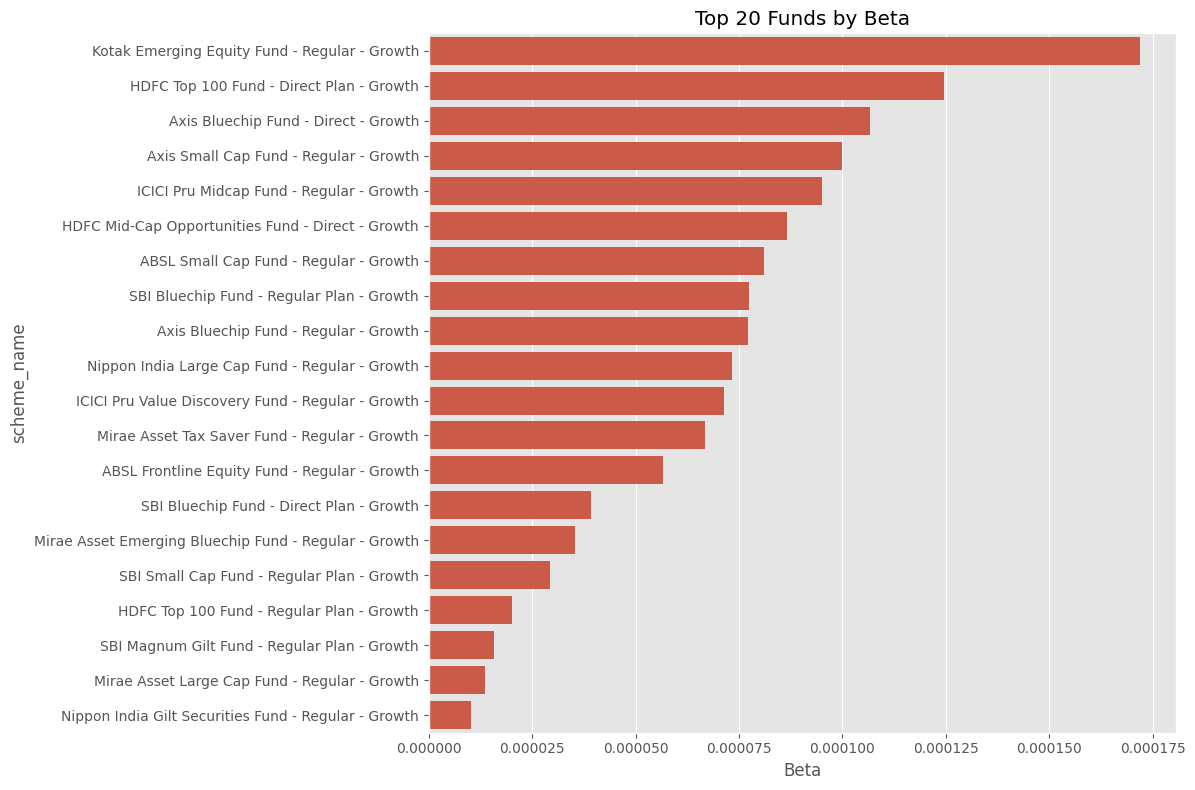

In [46]:
top20_beta = (
    alpha_beta
    .sort_values("Beta", ascending=False)
    .head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20_beta,
    x="Beta",
    y="scheme_name"
)

plt.title("Top 20 Funds by Beta")

plt.tight_layout()

plt.savefig(
    "../reports/beta_top20.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [47]:
mdd = nav.copy()

mdd = mdd.sort_values(
    ["amfi_code", "date"]
)

mdd["running_max"] = (
    mdd.groupby("amfi_code")["nav"]
    .cummax()
)

mdd.head()

,amfi_code,date,nav,daily_return,running_max
0,100016,2022-01-03,520.4608,NaN,520.4608
1,100016,2022-01-04,515.0971,-0.010306,520.4608
2,100016,2022-01-05,521.7239,0.012865,521.7239
3,100016,2022-01-06,515.7880,-0.011377,521.7239
4,100016,2022-01-07,515.1639,-0.001210,521.7239


In [48]:
mdd["drawdown"] = (
    mdd["nav"] / mdd["running_max"]
) - 1

mdd.head()

,amfi_code,date,nav,daily_return,running_max,drawdown
0,100016,2022-01-03,520.4608,NaN,520.4608,0.000000
1,100016,2022-01-04,515.0971,-0.010306,520.4608,-0.010306
2,100016,2022-01-05,521.7239,0.012865,521.7239,0.000000
3,100016,2022-01-06,515.7880,-0.011377,521.7239,-0.011377
4,100016,2022-01-07,515.1639,-0.001210,521.7239,-0.012574


In [49]:
max_drawdown = (
    mdd.groupby("amfi_code")["drawdown"]
    .min()
    .reset_index()
)

max_drawdown.rename(
    columns={"drawdown": "Maximum Drawdown"},
    inplace=True
)

max_drawdown.head()

,amfi_code,Maximum Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [50]:
max_drawdown = max_drawdown.merge(
    performance[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

max_drawdown.head()

,amfi_code,Maximum Drawdown,scheme_name
0,100016,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,-0.354469,ABSL Small Cap Fund - Regular - Growth


In [51]:
max_drawdown.to_csv(
    "../reports/maximum_drawdown.csv",
    index=False
)

print("Maximum Drawdown CSV Saved!")

Maximum Drawdown CSV Saved!


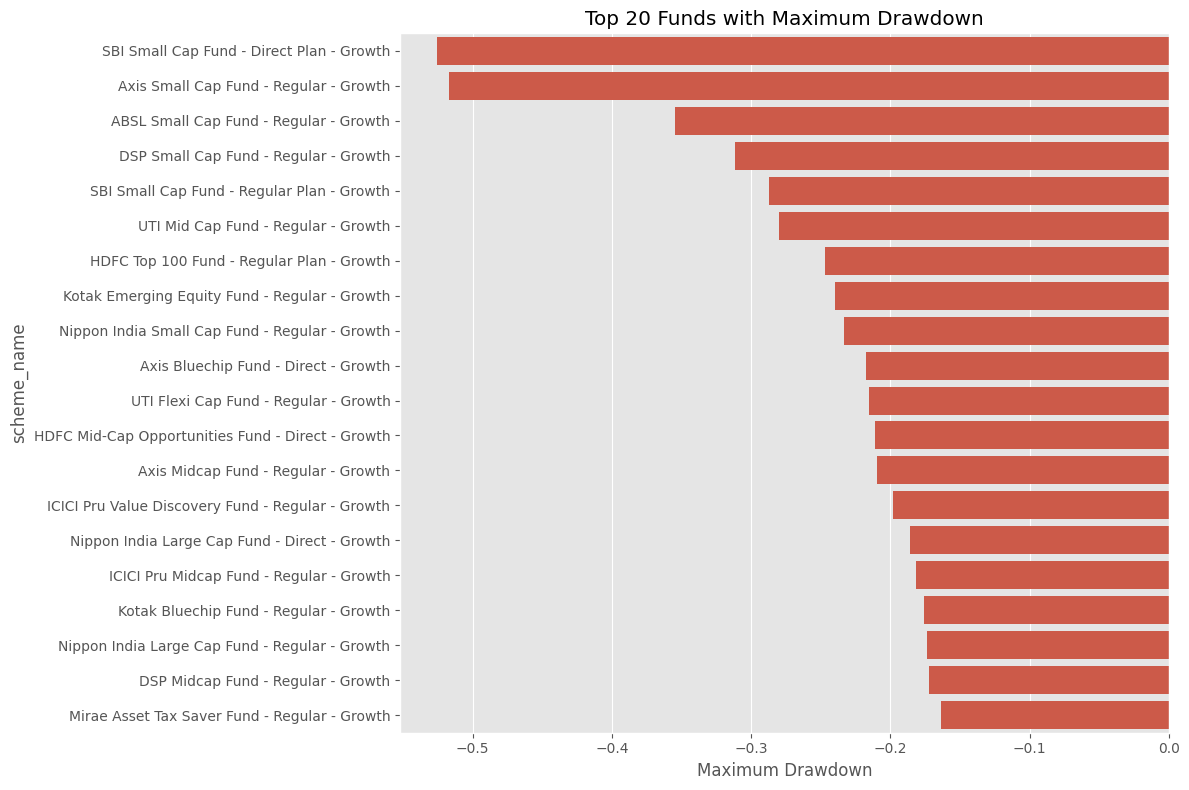

In [52]:
top20 = (
    max_drawdown
    .sort_values("Maximum Drawdown")
    .head(20)
)

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20,
    x="Maximum Drawdown",
    y="scheme_name"
)

plt.title("Top 20 Funds with Maximum Drawdown")

plt.tight_layout()

plt.savefig(
    "../reports/maximum_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [53]:
scorecard = cagr_df[cagr_df["Years"] == 3].copy()

scorecard = scorecard.rename(
    columns={"CAGR (%)": "Return_3Y"}
)

scorecard.head()

,amfi_code,Years,Return_3Y,scheme_name
1,100016,3,-0.03,HDFC Top 100 Fund - Regular Plan - Growth
3,100025,3,4.61,HDFC Short Term Debt Fund - Regular - Growth
5,100033,3,33.63,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
7,101206,3,32.53,ABSL Frontline Equity Fund - Regular - Growth
9,101207,3,-2.70,ABSL Small Cap Fund - Regular - Growth


In [54]:
scorecard = scorecard.merge(
    stats[["amfi_code", "Sharpe Ratio"]],
    on="amfi_code"
)

scorecard.head()

,amfi_code,Years,Return_3Y,scheme_name,Sharpe Ratio
0,100016,3,-0.03,HDFC Top 100 Fund - Regular Plan - Growth,-0.201517
1,100025,3,4.61,HDFC Short Term Debt Fund - Regular - Growth,-0.567095
2,100033,3,33.63,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
3,101206,3,32.53,ABSL Frontline Equity Fund - Regular - Growth,1.027213
4,101207,3,-2.70,ABSL Small Cap Fund - Regular - Growth,0.162661


In [55]:
scorecard = scorecard.merge(
    max_drawdown[
        ["amfi_code", "Maximum Drawdown"]
    ],
    on="amfi_code"
)

scorecard.head()

,amfi_code,Years,Return_3Y,scheme_name,Sharpe Ratio,Maximum Drawdown
0,100016,3,-0.03,HDFC Top 100 Fund - Regular Plan - Growth,-0.201517,-0.247344
1,100025,3,4.61,HDFC Short Term Debt Fund - Regular - Growth,-0.567095,-0.043083
2,100033,3,33.63,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,-0.162172
3,101206,3,32.53,ABSL Frontline Equity Fund - Regular - Growth,1.027213,-0.112916
4,101207,3,-2.70,ABSL Small Cap Fund - Regular - Growth,0.162661,-0.354469


In [57]:
print(scorecard.columns)

Index(['amfi_code', 'Years', 'Return_3Y', 'scheme_name', 'Sharpe Ratio',
       'Maximum Drawdown', 'Return Rank', 'Sharpe Rank'],
      dtype='object')


In [58]:
print(alpha_beta.columns)
alpha_beta.head()

Index(['amfi_code', 'Alpha', 'Beta', 'scheme_name'], dtype='object')


,amfi_code,Alpha,Beta,scheme_name
0,100016,0.023701,0.000020,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.049041,-0.000010,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.330252,-0.000098,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.181075,0.000057,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.058903,0.000081,ABSL Small Cap Fund - Regular - Growth


In [59]:
scorecard = scorecard.merge(
    alpha_beta[["amfi_code", "Alpha"]],
    on="amfi_code",
    how="left"
)

In [60]:
print(scorecard.columns)

Index(['amfi_code', 'Years', 'Return_3Y', 'scheme_name', 'Sharpe Ratio',
       'Maximum Drawdown', 'Return Rank', 'Sharpe Rank', 'Alpha'],
      dtype='object')


In [61]:
scorecard["Return Rank"] = scorecard["Return_3Y"].rank(ascending=False)

scorecard["Sharpe Rank"] = scorecard["Sharpe Ratio"].rank(ascending=False)

scorecard["Alpha Rank"] = scorecard["Alpha"].rank(ascending=False)

scorecard["Expense Rank"] = performance["expense_ratio_pct"].rank(ascending=True)

scorecard["Drawdown Rank"] = scorecard["Maximum Drawdown"].rank(ascending=False)

scorecard.head()

,amfi_code,Years,Return_3Y,scheme_name,Sharpe Ratio,Maximum Drawdown,Return Rank,Sharpe Rank,Alpha,Alpha Rank,Expense Rank,Drawdown Rank
0,100016,3,-0.03,HDFC Top 100 Fund - Regular Plan - Growth,-0.201517,-0.247344,36.0,35.0,0.023701,36.0,30.5,34.0
1,100025,3,4.61,HDFC Short Term Debt Fund - Regular - Growth,-0.567095,-0.043083,33.0,39.0,0.049041,32.0,4.0,4.0
2,100033,3,33.63,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,-0.162172,2.0,7.0,0.330252,1.0,21.0,20.0
3,101206,3,32.53,ABSL Frontline Equity Fund - Regular - Growth,1.027213,-0.112916,3.0,9.0,0.181075,16.0,5.5,9.0
4,101207,3,-2.70,ABSL Small Cap Fund - Regular - Growth,0.162661,-0.354469,39.0,28.0,0.058903,31.0,9.0,38.0


In [63]:
scorecard["Fund Score"] = (
      scorecard["Return Rank"] * 0.30
    + scorecard["Sharpe Rank"] * 0.25
    + scorecard["Alpha Rank"] * 0.20
    + scorecard["Expense Rank"] * 0.15
    + scorecard["Drawdown Rank"] * 0.10
)

scorecard["Fund Score"] = 100 - (
    (scorecard["Fund Score"] / scorecard["Fund Score"].max()) * 100
)

scorecard.head()

,amfi_code,Years,Return_3Y,scheme_name,Sharpe Ratio,Maximum Drawdown,Return Rank,Sharpe Rank,Alpha,Alpha Rank,Expense Rank,Drawdown Rank,Fund Score
0,100016,3,-0.03,HDFC Top 100 Fund - Regular Plan - Growth,-0.201517,-0.247344,36.0,35.0,0.023701,36.0,30.5,34.0,4.140787
1,100025,3,4.61,HDFC Short Term Debt Fund - Regular - Growth,-0.567095,-0.043083,33.0,39.0,0.049041,32.0,4.0,4.0,25.327812
2,100033,3,33.63,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,-0.162172,2.0,7.0,0.330252,1.0,21.0,20.0,78.743961
3,101206,3,32.53,ABSL Frontline Equity Fund - Regular - Growth,1.027213,-0.112916,3.0,9.0,0.181075,16.0,5.5,9.0,77.708765
4,101207,3,-2.70,ABSL Small Cap Fund - Regular - Growth,0.162661,-0.354469,39.0,28.0,0.058903,31.0,9.0,38.0,17.046239


In [64]:
scorecard = scorecard.sort_values(
    "Fund Score",
    ascending=False
)

scorecard.head(10)

,amfi_code,Years,Return_3Y,scheme_name,Sharpe Ratio,Maximum Drawdown,Return Rank,Sharpe Rank,Alpha,Alpha Rank,Expense Rank,Drawdown Rank,Fund Score
34,148567,3,31.28,Mirae Asset Large Cap Fund - Regular - Growth,1.448291,-0.112657,4.0,1.0,0.262504,7.0,23.0,8.0,80.400276
16,119094,3,36.07,Axis Midcap Fund - Regular - Growth,0.998231,-0.209609,1.0,11.0,0.303408,3.0,5.5,28.0,79.917184
30,120843,3,25.66,Kotak Flexicap Fund - Regular - Growth,1.306744,-0.129740,9.5,2.0,0.279736,5.0,11.0,13.0,79.848171
2,100033,3,33.63,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699,-0.162172,2.0,7.0,0.330252,1.0,21.0,20.0,78.743961
3,101206,3,32.53,ABSL Frontline Equity Fund - Regular - Growth,1.027213,-0.112916,3.0,9.0,0.181075,16.0,5.5,9.0,77.708765
19,119551,3,27.73,SBI Bluechip Fund - Regular Plan - Growth,1.208267,-0.150124,8.0,4.0,0.185141,15.0,1.0,17.0,77.225673
25,120505,3,30.21,ICICI Pru Midcap Fund - Regular - Growth,1.180101,-0.181885,5.0,5.0,0.236335,11.0,8.0,25.0,76.121463
24,120504,3,28.37,ICICI Pru Bluechip Fund - Direct - Growth,1.026524,-0.125883,6.0,10.0,0.249913,8.0,39.5,12.0,64.044168
9,118632,3,18.09,Nippon India Large Cap Fund - Regular - Growth,1.081659,-0.174141,17.0,8.0,0.174565,18.0,2.0,23.0,63.285024
36,148569,3,23.32,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930,-0.163967,13.0,3.0,0.243740,9.0,36.5,21.0,61.283644


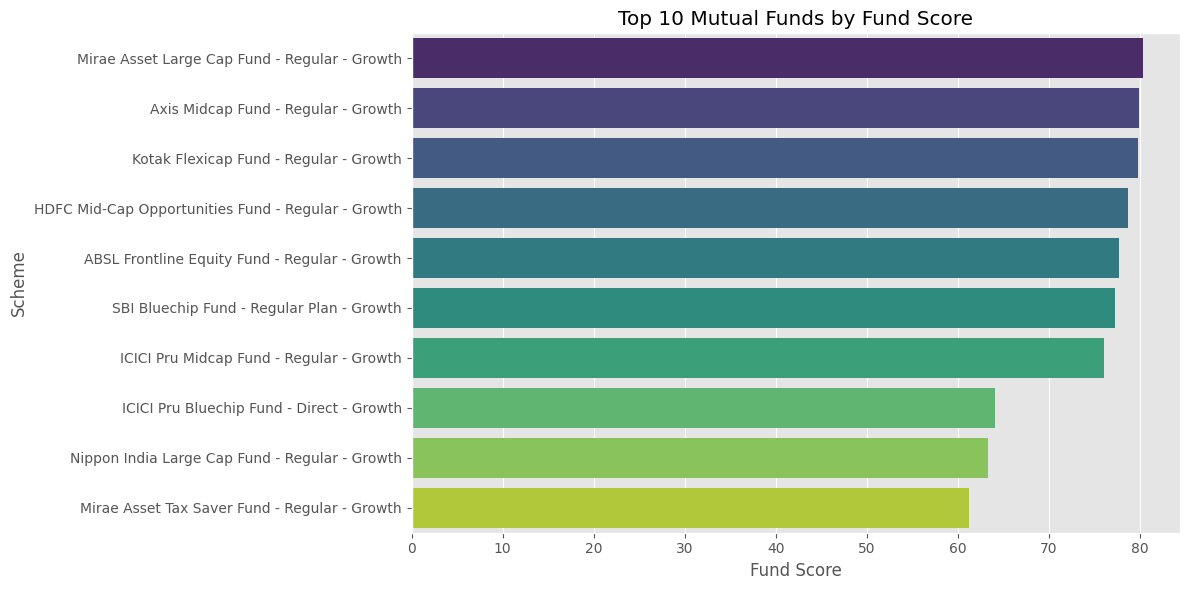

In [65]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=scorecard.head(10),
    x="Fund Score",
    y="scheme_name",
    palette="viridis"
)

plt.title("Top 10 Mutual Funds by Fund Score")

plt.xlabel("Fund Score")

plt.ylabel("Scheme")

plt.tight_layout()

plt.savefig("../reports/fund_scorecard.png")

plt.show()

In [66]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

In [67]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

In [69]:
top5 = scorecard.head(5)["amfi_code"]

top5_returns = daily_returns[
    daily_returns["amfi_code"].isin(top5)
].copy()

top5_returns.head()

,amfi_code,date,nav,daily_return
2301,100033,2022-01-04,105.9447,-0.013328
2302,100033,2022-01-05,105.4800,-0.004386
2303,100033,2022-01-06,104.9350,-0.005167
2304,100033,2022-01-07,104.3318,-0.005748
2305,100033,2022-01-10,104.9867,0.006277


In [70]:
top5_returns = top5_returns.merge(
    performance[["amfi_code", "scheme_name"]],
    on="amfi_code"
)

top5_returns.head()

,amfi_code,date,nav,daily_return,scheme_name
0,100033,2022-01-04,105.9447,-0.013328,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
1,100033,2022-01-05,105.4800,-0.004386,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,100033,2022-01-06,104.9350,-0.005167,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,100033,2022-01-07,104.3318,-0.005748,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
4,100033,2022-01-10,104.9867,0.006277,HDFC Mid-Cap Opportunities Fund - Regular - Gr...


In [71]:
benchmark50 = benchmark[
    benchmark["index_name"] == "NIFTY50"
].copy()

benchmark100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

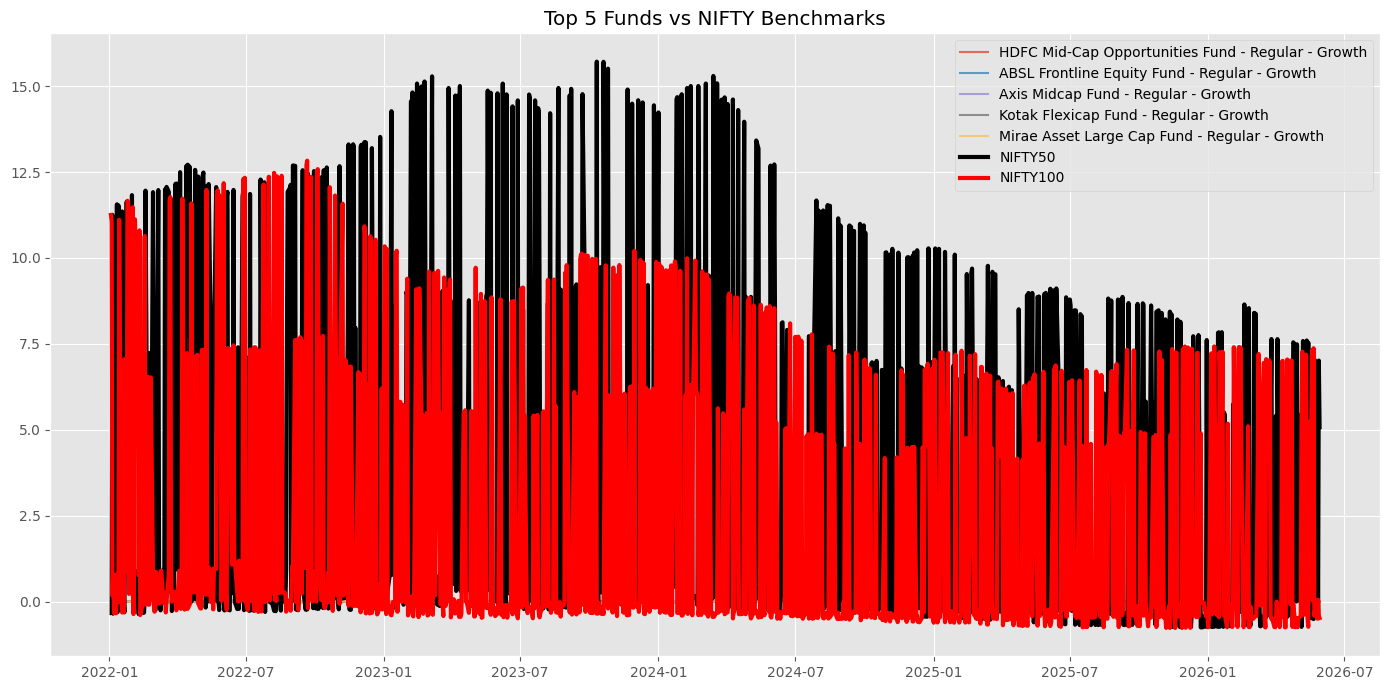

In [72]:
plt.figure(figsize=(14,7))

for scheme in top5_returns["scheme_name"].unique():
    temp = top5_returns[
        top5_returns["scheme_name"] == scheme
    ]

    plt.plot(
        temp["date"],
        temp["daily_return"],
        alpha=0.8,
        label=scheme
    )

plt.plot(
    benchmark50["date"],
    benchmark50["benchmark_return"],
    linewidth=3,
    color="black",
    label="NIFTY50"
)

plt.plot(
    benchmark100["date"],
    benchmark100["benchmark_return"],
    linewidth=3,
    color="red",
    label="NIFTY100"
)

plt.legend()

plt.title("Top 5 Funds vs NIFTY Benchmarks")

plt.tight_layout()

plt.savefig("../reports/benchmark_comparison.png")

plt.show()